In [2]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import seaborn as sns

# Goal
- Create a figure with 2 boxplots. 
- The boxplots should come from two different distributions:
1. Gaussian Distribution - bell-shaped curve where values cluster around a mean, with probability tapering off symmetrically toward the tails. Most values fall near the center; extreme values are rare. Emerge from the sum of many independent random variables - heights, measurement errors, IQ scores, etc. These distributions take parameters $\mu$  (mean) and $\sigma$ (standard deviation).
2. Uniform Distribution - Every value within a range has equal probabilit. The probability density is flat - no clustering, no tails. Emerge from situations where all outcomes are equally likely - rolling a fair die, random number generators, random sampling. These distributions take the parameters $min$ and $max$. 

## Questions I Had
1. I understand how we can generate data from a normal distribution: all the numbers will center around the same mean. But what does it mean to generate data from a uniform distribution?
- When you generate 10 numbers from a normal distriubtion (mean=0, std=1), you'd get something like:
`[-0.3, 1.2, 0.1, -1.8, 0.5, 0.2, -0.4, 2.1, 0.0, -0.6]`

Numbers near 0 are common; numbers near $\pm 2$ are rare.

When you generate 10 numbers from a uniform distribution (min=0, max=1), you'd get something like:
`[0.83, 0.12, 0.47, 0.91, 0.05, 0.66, 0.38, 0.74, 0.22, 0.59]`. 

Notice: no clustering. Values are spread roughly evenly across the whole range. A value of 0.05 is just as likely as 0.50 or 0.95. 

In [3]:
num_data_points = 10

In [4]:

normal_data = np.random.randn(num_data_points)
print(normal_data)

[ 1.30404508 -0.15204705  1.90666864 -0.14456921 -1.42542581 -0.49528466
  0.02021939  1.15329341  1.09479632 -0.55543781]


In [5]:
uniform_data = np.random.rand(num_data_points)
print(uniform_data)

[0.81761043 0.96881994 0.08624097 0.33282094 0.11885442 0.63975655
 0.37279648 0.34458937 0.61977569 0.41418623]


## Expecations: Normal vs Uniform Box Plots
- Normal box plot will be shorter, as the spread will be smaller since most data is clustered around the mean. 

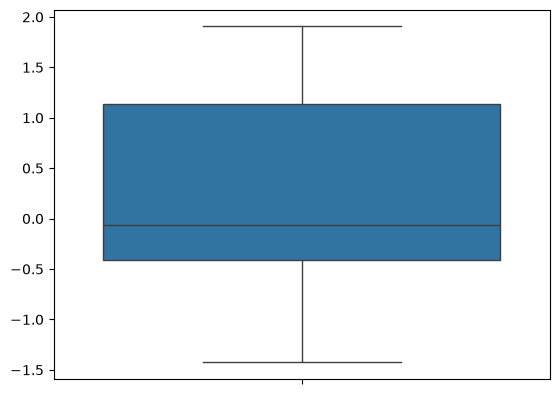

In [7]:
sns.boxplot(data=normal_data)
plt.show()

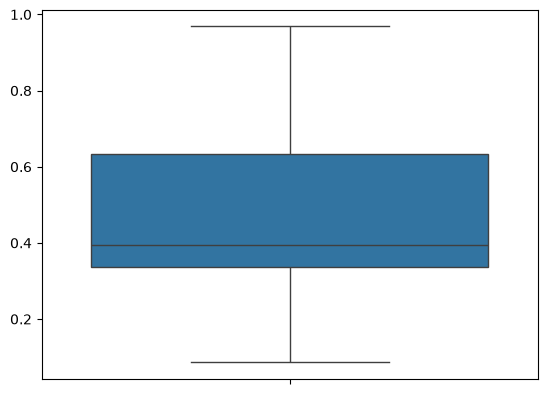

In [8]:
sns.boxplot(data=uniform_data)
plt.show()

In [10]:
# Combining the two datasets into one so we can view them on the same graph
all_data = np.zeros((num_data_points, 2))
all_data

array([[0., 0.],
       [0., 0.],
       [0., 0.],
       [0., 0.],
       [0., 0.],
       [0., 0.],
       [0., 0.],
       [0., 0.],
       [0., 0.],
       [0., 0.]])

In [11]:
all_data[:, 0] = normal_data
all_data[:, 1] = uniform_data
all_data

array([[ 1.30404508,  0.81761043],
       [-0.15204705,  0.96881994],
       [ 1.90666864,  0.08624097],
       [-0.14456921,  0.33282094],
       [-1.42542581,  0.11885442],
       [-0.49528466,  0.63975655],
       [ 0.02021939,  0.37279648],
       [ 1.15329341,  0.34458937],
       [ 1.09479632,  0.61977569],
       [-0.55543781,  0.41418623]])

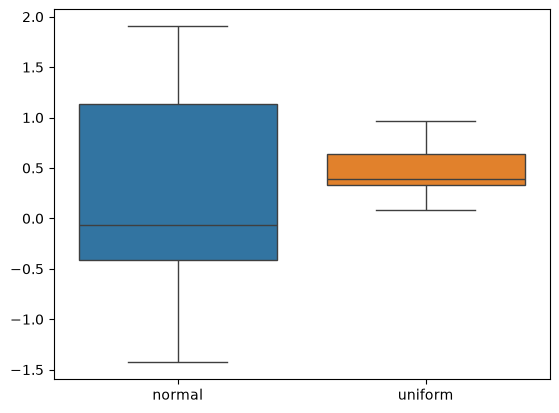

In [15]:
df = pd.DataFrame(all_data, columns=["normal", "uniform"])
sns.boxplot(df)
plt.show()

## Actual Outcome
- "Clustering around the mean" does not mean the distribution is narrow. It just means probability is concentrated there - but the values can still spread far. 
- The actual spreads:
    - Standard normal (mean=0, std=1): values typically range from roughly -3 to +3 (range $\approx$ 6)
    - Standard uniform (min=0, max=1): values are hard-capped at 0 and 1 (range = 1, max)
- The uniform distribution is actually much tighter because it has strict boundaries.
- The normal distribution has no walls. That's what the tails represent. 
